# Lab 2: Simulating RelWeights

This lab builds a full Monte Carlo comparison between two ideas of autocorrelation:

1. **ordinary geographic autocorrelation** using a first-order contiguity matrix $W$ on a $10 \times 10$ lattice, and
2. **contextual autocorrelation** using a RelWeights matrix

$$
R = B B^{\top},
$$

where $B$ is a stacked incidence matrix built from two irregular overlay supports.

The motivation of this module is that Geographic adjacency is only one way to define a spatial graph. In this notebook, the default geographic baseline is **queen contiguity**, but the code exposes a one-line toggle back to rook contiguity you can compare both first-order conventions. If a process is generated by shared overlay supports rather than by same-layer contiguity, then a contextual similarity graph should explain the autocorrelation structure better than an ordinary geographic matrix [@anselin1988; @geary1954; @chung1997spectral].

## 1. Introduction and learning goals

By the end of this lab, you should be able to:

- construct a geographic weights matrix $W$ on a lattice
- construct a RelWeights matrix $R$ from multiple overlay supports
- form the graph Laplacians

$$
L_W = D_W - W, \qquad L_R = D_R - R
$$

- compute raw Laplacian energies and normalized Geary-style statistics
- interpret global and local Geary as normalized Laplacian energy
- use Monte Carlo simulation to compare whether a process is better explained by geographic support or contextual support

## 2. Mathematical background

We center any signal $x$ by defining

$$
z = x - \bar{x}\mathbf{1}.
$$

The raw Laplacian energies are

$$
E_W(x) = z^{\top}L_W z, \qquad E_R(x) = z^{\top}L_R z.
$$

These are the unnormalized numerators of Geary's $C$ [@geary1954]. The normalized global statistics are

$$
C_W = \frac{n-1}{S_{0,W}} \cdot \frac{z^{\top}L_W z}{z^{\top}z},
\qquad
C_R = \frac{n-1}{S_{0,R}} \cdot \frac{z^{\top}L_R z}{z^{\top}z},
$$

where

$$
S_{0,W} = \sum_i\sum_j W_{ij},
\qquad
S_{0,R} = \sum_i\sum_j R_{ij}.
$$

Interpretation:

- if Geary is near `1`, the process looks random relative to that support
- if Geary is well below `1`, the process is smooth or autocorrelated relative to that support
- if `C_W < C_R`, geographic support explains the process better
- if `C_R < C_W`, contextual overlay support explains the process better

For local diagnostics, define

$$
E_i(W) = \frac{1}{2}\sum_j W_{ij}(z_i - z_j)^2,
\qquad
E_i(R) = \frac{1}{2}\sum_j R_{ij}(z_i - z_j)^2
$$

and the local Geary statistics

$$
c_i(W) = \frac{1}{m_2}\sum_j W_{ij}(z_i - z_j)^2,
\qquad
c_i(R) = \frac{1}{m_2}\sum_j R_{ij}(z_i - z_j)^2,
$$

with

$$
m_2 = \frac{\sum_i z_i^2}{n-1}.
$$

So:

- **raw Laplacian energy** measures total or local roughness directly
- **Geary's $C$** is normalized Laplacian energy
- **local Geary** is normalized local Laplacian energy

One caution matters throughout the lab: raw energies are not directly comparable across graphs with different total edge weight. That is why the normalization in Geary's $C$ is useful.

## 3. Build the 10x10 lattice and geographic weights

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, Iterable, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap

In [2]:
SEED = 20260419
N_ROWS = 10
N_COLS = 10
N_CELLS = N_ROWS * N_COLS
GEOGRAPHIC_CONTIGUITY = "queen"

FINE_REGION_RANGE = (18, 22)
COARSE_REGION_RANGE = (7, 10)
N_MONTE_CARLO = 150

GEOGRAPHIC_STEPS = 25
GEOGRAPHIC_BLEND = 0.30
GEOGRAPHIC_INNOVATION = 0.20

CONTEXTUAL_NOISE = 0.35
MIXED_GEO_WEIGHT = 0.70
MIXED_CTX_WEIGHT = 0.70
MIXED_NOISE = 0.20

INCLUDE_CROSS_SUPPORT = True

SCENARIO_ORDER = [
    "iid_noise",
    "geographic_only",
    "contextual_only",
    "mixed",
]
if INCLUDE_CROSS_SUPPORT:
    SCENARIO_ORDER.append("cross_support_optional")

plt.rcParams["figure.figsize"] = (7, 6)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

In [3]:
def cell_index(row: int, col: int, n_cols: int = N_COLS) -> int:
    """Map a row/column coordinate to a single cell index."""

    return row * n_cols + col


def row_col(index: int, n_cols: int = N_COLS) -> tuple[int, int]:
    """Map a cell index back to its row/column coordinates."""

    return divmod(index, n_cols)


def build_rook_neighbors(n_rows: int = N_ROWS, n_cols: int = N_COLS) -> dict[int, list[int]]:
    """Return rook neighbors for every lattice cell."""

    neighbors: dict[int, list[int]] = {i: [] for i in range(n_rows * n_cols)}
    for r in range(n_rows):
        for c in range(n_cols):
            i = cell_index(r, c, n_cols)
            for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                rr, cc = r + dr, c + dc
                if 0 <= rr < n_rows and 0 <= cc < n_cols:
                    neighbors[i].append(cell_index(rr, cc, n_cols))
    return neighbors


def build_geographic_neighbors(
    n_rows: int = N_ROWS,
    n_cols: int = N_COLS,
    style: str = GEOGRAPHIC_CONTIGUITY,
) -> dict[int, list[int]]:
    """Return first-order rook or queen neighbors for every lattice cell."""

    style = style.lower()
    if style not in {"queen", "rook"}:
        raise ValueError("style must be either 'queen' or 'rook'")

    offsets = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    if style == "queen":
        offsets += [(-1, -1), (-1, 1), (1, -1), (1, 1)]

    neighbors: dict[int, list[int]] = {i: [] for i in range(n_rows * n_cols)}
    for r in range(n_rows):
        for c in range(n_cols):
            i = cell_index(r, c, n_cols)
            for dr, dc in offsets:
                rr, cc = r + dr, c + dc
                if 0 <= rr < n_rows and 0 <= cc < n_cols:
                    neighbors[i].append(cell_index(rr, cc, n_cols))
    return neighbors


def geographic_weights_matrix(
    n_rows: int = N_ROWS,
    n_cols: int = N_COLS,
    style: str = GEOGRAPHIC_CONTIGUITY,
) -> np.ndarray:
    """Construct the binary geographic weights matrix W under rook or queen contiguity."""

    neighbors = build_geographic_neighbors(n_rows, n_cols, style=style)
    W = np.zeros((n_rows * n_cols, n_rows * n_cols), dtype=float)
    for i, nbs in neighbors.items():
        W[i, nbs] = 1.0
    return W


def row_standardize(W: np.ndarray) -> np.ndarray:
    """Row-standardize a weight matrix when row sums are positive."""

    row_sums = W.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    return W / row_sums


GEOGRAPHIC_LABEL = GEOGRAPHIC_CONTIGUITY.title()
W = geographic_weights_matrix(style=GEOGRAPHIC_CONTIGUITY)
W_row = row_standardize(W)
L_W = np.diag(W.sum(axis=1)) - W

print(f"Lattice size: {N_ROWS}x{N_COLS} = {N_CELLS} cells")
print(f"Total geographic edge weight S0_W: {W.sum():.0f}")
print(f"Geographic baseline: {GEOGRAPHIC_LABEL}")
print(f"Average {GEOGRAPHIC_LABEL.lower()} degree: {W.sum(axis=1).mean():.2f}")

Lattice size: 10x10 = 100 cells
Total geographic edge weight S0_W: 684
Geographic baseline: Queen
Average queen degree: 6.84


If you want to switch the simulation baseline, change `GEOGRAPHIC_CONTIGUITY` between `"queen"` and `"rook"` and rerun the notebook. The Monte Carlo comparison will then read as queen-vs-RelWeights or rook-vs-RelWeights without changing the rest of the code.

## 4. Build irregular overlay layers

The contextual graph will be induced by **two connected irregular partitions** of the same lattice:

- Layer 1: finer support with roughly 18 to 22 regions
- Layer 2: coarser support with roughly 7 to 10 regions

Each layer is created by seeded growth. Therefore, every region is connected because it grows outward from a seed through rook adjacency.

In [5]:
def draw_region_count(bounds: tuple[int, int], rng: np.random.Generator) -> int:
    """Draw a region count uniformly from an inclusive integer range."""

    low, high = bounds
    return int(rng.integers(low, high + 1))


def region_targets(n_cells: int, n_regions: int, rng: np.random.Generator, concentration: float = 1.5) -> np.ndarray:
    """Generate positive integer target sizes that sum to n_cells."""

    raw = rng.dirichlet(np.full(n_regions, concentration))
    sizes = np.floor(raw * (n_cells - n_regions)).astype(int) + 1
    diff = int(n_cells - sizes.sum())

    while diff != 0:
        if diff > 0:
            j = int(rng.integers(0, n_regions))
            sizes[j] += 1
            diff -= 1
        else:
            candidates = np.where(sizes > 1)[0]
            j = int(rng.choice(candidates))
            sizes[j] -= 1
            diff += 1

    return sizes


def grow_connected_partition(
    n_rows: int,
    n_cols: int,
    n_regions: int,
    rng: np.random.Generator,
    concentration: float = 1.5,
) -> np.ndarray:
    """Create a connected irregular partition by seeded growth.

    Every region starts from one seed cell and can only grow through rook-adjacent
    frontier cells. This guarantees connected regions by construction.
    """

    n_cells = n_rows * n_cols
    neighbors = build_rook_neighbors(n_rows, n_cols)
    seeds = rng.choice(n_cells, size=n_regions, replace=False)
    labels = np.full(n_cells, -1, dtype=int)

    targets = region_targets(n_cells, n_regions, rng, concentration=concentration)
    remaining = targets.copy()
    frontiers = [set() for _ in range(n_regions)]

    for region, seed in enumerate(seeds):
        labels[seed] = region
        remaining[region] -= 1
        frontiers[region].update(neighbors[seed])

    while np.any(labels == -1):
        available = []
        weights = []

        for region in range(n_regions):
            frontiers[region] = {cell for cell in frontiers[region] if labels[cell] == -1}
            if frontiers[region]:
                available.append(region)
                weights.append(max(remaining[region], 1))

        if not available:
            raise RuntimeError("Partition growth stalled: no frontier cells remained.")

        weights = np.asarray(weights, dtype=float)
        weights = weights / weights.sum()
        region = int(rng.choice(available, p=weights))
        frontier_cells = list(frontiers[region])
        cell = int(rng.choice(frontier_cells))

        labels[cell] = region
        remaining[region] -= 1
        frontiers[region].discard(cell)

        for nb in neighbors[cell]:
            if labels[nb] == -1:
                frontiers[region].add(nb)

    return labels


def partition_to_grid(labels: np.ndarray, n_rows: int = N_ROWS, n_cols: int = N_COLS) -> np.ndarray:
    """Reshape a flat partition label vector into a grid for plotting."""

    return labels.reshape(n_rows, n_cols)


def incidence_from_partition(labels: np.ndarray) -> np.ndarray:
    """Convert region labels into a one-hot incidence matrix B."""

    labels = np.asarray(labels, dtype=int)
    n = labels.size
    k = int(labels.max()) + 1
    B = np.zeros((n, k), dtype=float)
    B[np.arange(n), labels] = 1.0
    return B


def plot_partition(labels: np.ndarray, title: str) -> None:
    """Plot a partition as a colored lattice grid."""

    grid = partition_to_grid(labels)
    cmap = ListedColormap(plt.cm.tab20(np.linspace(0, 1, max(grid.max() + 1, 3))))
    fig, ax = plt.subplots()
    im = ax.imshow(grid, cmap=cmap, interpolation="none")
    ax.set_title(title)
    ax.set_xticks(np.arange(-0.5, N_COLS, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, N_ROWS, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.0)
    ax.set_xticks(range(N_COLS))
    ax.set_yticks(range(N_ROWS))
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
    plt.show()

In [6]:
rng_demo = np.random.default_rng(SEED)
demo_k1 = draw_region_count(FINE_REGION_RANGE, rng_demo)
demo_k2 = draw_region_count(COARSE_REGION_RANGE, rng_demo)
demo_labels1 = grow_connected_partition(N_ROWS, N_COLS, demo_k1, rng_demo, concentration=1.7)
demo_labels2 = grow_connected_partition(N_ROWS, N_COLS, demo_k2, rng_demo, concentration=1.2)

print(f"Demo Layer 1 regions: {demo_k1}")
print(f"Demo Layer 2 regions: {demo_k2}")

Demo Layer 1 regions: 22
Demo Layer 2 regions: 10


## 5. Build B, R, and L_R

In [7]:
B1_demo = incidence_from_partition(demo_labels1)
B2_demo = incidence_from_partition(demo_labels2)
B_demo = np.hstack([B1_demo, B2_demo])

R_demo = B_demo @ B_demo.T
np.fill_diagonal(R_demo, 0.0)
L_R_demo = np.diag(R_demo.sum(axis=1)) - R_demo

print("Shapes")
print("B1:", B1_demo.shape)
print("B2:", B2_demo.shape)
print("B :", B_demo.shape)
print("R :", R_demo.shape)
print("Total contextual edge weight S0_R:", R_demo.sum())

Shapes
B1: (100, 22)
B2: (100, 10)
B : (100, 32)
R : (100, 100)
Total contextual edge weight S0_R: 1656.0


The stacked incidence matrix

$$
B = [B_1 \mid B_2]
$$

is the key move. Each cell belongs to one region in Layer 1 and one region in Layer 2. Multiplying $B$ by its transpose counts shared support memberships. After zeroing the diagonal, the result is a **contextual similarity graph** on the base lattice.

## 6. Define Laplacian energy and Geary statistics

In [8]:
def center_signal(x: np.ndarray) -> np.ndarray:
    """Center a signal by subtracting its mean."""

    return np.asarray(x, dtype=float) - np.mean(x)


def laplacian_from_weights(W: np.ndarray) -> np.ndarray:
    """Construct D - W from a weight matrix."""

    return np.diag(W.sum(axis=1)) - W


def raw_laplacian_energy(x: np.ndarray, W: np.ndarray) -> float:
    """Return z' L z for the centered version of x."""

    z = center_signal(x)
    L = laplacian_from_weights(W)
    return float(z.T @ L @ z)


def geary_statistic(x: np.ndarray, W: np.ndarray) -> tuple[float, float, np.ndarray]:
    """Return raw Laplacian energy, Geary C, and the centered signal."""

    z = center_signal(x)
    denom = float(z.T @ z)
    S0 = float(W.sum())
    energy = raw_laplacian_energy(x, W)

    if S0 == 0 or denom == 0:
        return energy, np.nan, z

    C = ((len(z) - 1) / S0) * energy / denom
    return energy, float(C), z


def local_energy(z: np.ndarray, W: np.ndarray) -> np.ndarray:
    """Compute local Laplacian energy contributions."""

    diff_sq = (z[:, None] - z[None, :]) ** 2
    return 0.5 * np.sum(W * diff_sq, axis=1)


def local_geary(z: np.ndarray, W: np.ndarray) -> np.ndarray:
    """Compute normalized local Geary values."""

    m2 = float(np.sum(z**2) / (len(z) - 1))
    diff_sq = (z[:, None] - z[None, :]) ** 2
    return np.sum(W * diff_sq, axis=1) / m2


def standardize_signal(x: np.ndarray) -> np.ndarray:
    """Standardize a signal to mean zero and variance one."""

    x = np.asarray(x, dtype=float)
    return (x - x.mean()) / (x.std(ddof=0) + 1e-12)

In [9]:
demo_geo = standardize_signal(np.linspace(-1, 1, N_CELLS))
demo_E_W, demo_C_W, _ = geary_statistic(demo_geo, W)
demo_E_R, demo_C_R, _ = geary_statistic(demo_geo, R_demo)

print(f"Demo E_W: {demo_E_W:,.2f}")
print(f"Demo C_W: {demo_C_W:.3f}")
print(f"Demo E_R: {demo_E_R:,.2f}")
print(f"Demo C_R: {demo_C_R:.3f}")

Demo E_W: 30.55
Demo C_W: 0.044
Demo E_R: 505.15
Demo C_R: 0.302


The important logic is:

- raw energy is the numerator
- Geary's $C$ is the normalized version
- local energy and local Geary tell us **where** roughness is concentrated

## 7. Visualize the supports

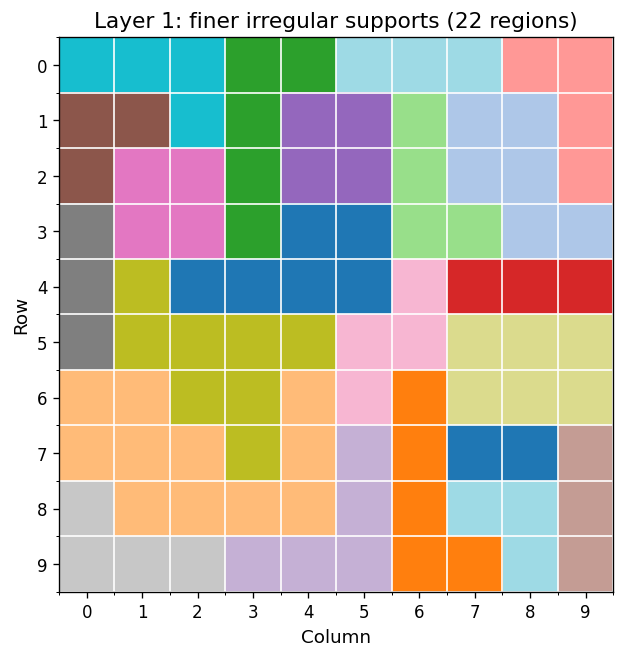

In [10]:
plot_partition(demo_labels1, f"Layer 1: finer irregular supports ({demo_k1} regions)")

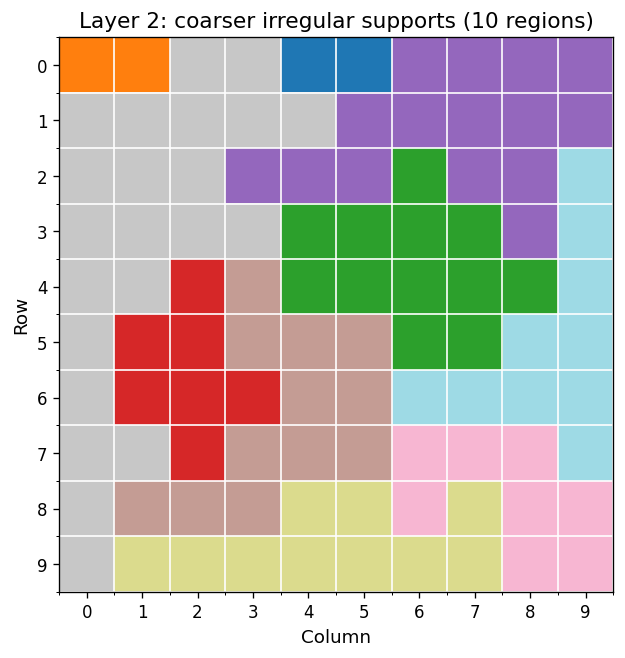

In [11]:
plot_partition(demo_labels2, f"Layer 2: coarser irregular supports ({demo_k2} regions)")

These colored grid cells are a pedagogical proxy for irregular polygons. What matters is that they form connected support regions and that the two layers impose different non-geographic neighborhood structures on the same base lattice.

## 8. Simulate the four DGPs

In [12]:
def simulate_iid_noise(n: int, rng: np.random.Generator) -> np.ndarray:
    """Scenario 1: iid Gaussian noise."""

    return standardize_signal(rng.normal(size=n))


def simulate_geographic_component(
    W_row: np.ndarray,
    rng: np.random.Generator,
    steps: int = GEOGRAPHIC_STEPS,
    blend: float = GEOGRAPHIC_BLEND,
    innovation_scale: float = GEOGRAPHIC_INNOVATION,
) -> np.ndarray:
    """Scenario component: spatially smooth field created by iterative neighbor averaging."""

    x = rng.normal(size=W_row.shape[0])
    for _ in range(steps):
        x = (1.0 - blend) * x + blend * (W_row @ x) + rng.normal(scale=innovation_scale, size=x.size)
    return standardize_signal(x)


def simulate_contextual_component(
    labels1: np.ndarray,
    labels2: np.ndarray,
    rng: np.random.Generator,
    noise_scale: float = CONTEXTUAL_NOISE,
) -> np.ndarray:
    """Scenario component: additive overlay random effects plus noise."""

    effect1 = rng.normal(scale=1.0, size=int(labels1.max()) + 1)
    effect2 = rng.normal(scale=1.2, size=int(labels2.max()) + 1)
    x = effect1[labels1] + effect2[labels2] + rng.normal(scale=noise_scale, size=labels1.size)
    return standardize_signal(x)


def simulate_mixed_process(
    W_row: np.ndarray,
    labels1: np.ndarray,
    labels2: np.ndarray,
    rng: np.random.Generator,
) -> np.ndarray:
    """Scenario 4: mixture of geographic and contextual structure."""

    geographic = simulate_geographic_component(W_row, rng)
    contextual = simulate_contextual_component(labels1, labels2, rng, noise_scale=0.0)
    x = (
        MIXED_GEO_WEIGHT * geographic
        + MIXED_CTX_WEIGHT * contextual
        + rng.normal(scale=MIXED_NOISE, size=geographic.size)
    )
    return standardize_signal(x)


def simulate_cross_support_process(
    W_row: np.ndarray,
    B: np.ndarray,
    rng: np.random.Generator,
) -> np.ndarray:
    """Optional Scenario 5: base-layer field plus inherited overlay effect."""

    x_alpha = simulate_geographic_component(W_row, rng, steps=12, blend=0.20, innovation_scale=0.15)
    beta = rng.normal(scale=1.0, size=B.shape[1])
    inherited = standardize_signal(B @ beta)
    x = 0.20 * x_alpha + 1.10 * inherited + rng.normal(scale=0.15, size=x_alpha.size)
    return standardize_signal(x)


def simulate_scenarios(
    W_row: np.ndarray,
    labels1: np.ndarray,
    labels2: np.ndarray,
    B: np.ndarray,
    rng: np.random.Generator,
) -> dict[str, np.ndarray]:
    """Generate all scenarios for one replication."""

    scenarios = {
        "iid_noise": simulate_iid_noise(B.shape[0], rng),
        "geographic_only": simulate_geographic_component(W_row, rng),
        "contextual_only": simulate_contextual_component(labels1, labels2, rng),
        "mixed": simulate_mixed_process(W_row, labels1, labels2, rng),
    }
    if INCLUDE_CROSS_SUPPORT:
        scenarios["cross_support_optional"] = simulate_cross_support_process(W_row, B, rng)
    return scenarios

In [13]:
demo_scenarios = simulate_scenarios(W_row, demo_labels1, demo_labels2, B_demo, np.random.default_rng(SEED + 99))

for name in SCENARIO_ORDER:
    E_W, C_W, _ = geary_statistic(demo_scenarios[name], W)
    E_R, C_R, _ = geary_statistic(demo_scenarios[name], R_demo)
    print(f"{name:24s}  Geary_W={C_W:6.3f}  Geary_R={C_R:6.3f}  Energy_W={E_W:9.2f}  Energy_R={E_R:9.2f}")

iid_noise                 Geary_W= 1.101  Geary_R= 0.956  Energy_W=   760.75  Energy_R=  1599.84
geographic_only           Geary_W= 0.498  Geary_R= 0.664  Energy_W=   344.32  Energy_R=  1110.05
contextual_only           Geary_W= 0.410  Geary_R= 0.241  Energy_W=   283.18  Energy_R=   402.67
mixed                     Geary_W= 0.767  Geary_R= 0.601  Energy_W=   529.64  Energy_R=  1004.51
cross_support_optional    Geary_W= 0.502  Geary_R= 0.354  Energy_W=   346.80  Energy_R=   591.39


Even before Monte Carlo, the qualitative expectation is:

- `iid_noise`: both statistics should be near `1`
- `geographic_only`: `C_W` should be lower than `C_R`
- `contextual_only`: `C_R` should be lower than `C_W`
- `mixed`: both supports should show signal

## 9. Run Monte Carlo

In [14]:
@dataclass
class WorkedExample:
    """Container for one selected draw and its local diagnostics."""

    labels1: np.ndarray
    labels2: np.ndarray
    x: np.ndarray
    local_geary_w: np.ndarray
    local_geary_r: np.ndarray
    local_energy_w: np.ndarray
    local_energy_r: np.ndarray


def run_monte_carlo(
    n_replications: int,
    seed: int = SEED,
) -> tuple[pd.DataFrame, WorkedExample]:
    """Run the full Monte Carlo experiment and return results plus one worked example."""

    records: list[dict[str, float | int | str]] = []
    worked_example: WorkedExample | None = None

    for rep in range(n_replications):
        rng = np.random.default_rng(seed + rep)

        n_layer1 = draw_region_count(FINE_REGION_RANGE, rng)
        n_layer2 = draw_region_count(COARSE_REGION_RANGE, rng)

        labels1 = grow_connected_partition(N_ROWS, N_COLS, n_layer1, rng, concentration=1.7)
        labels2 = grow_connected_partition(N_ROWS, N_COLS, n_layer2, rng, concentration=1.2)

        B1 = incidence_from_partition(labels1)
        B2 = incidence_from_partition(labels2)
        B = np.hstack([B1, B2])
        R = B @ B.T
        np.fill_diagonal(R, 0.0)

        scenarios = simulate_scenarios(W_row, labels1, labels2, B, rng)

        for scenario, x in scenarios.items():
            energy_w, geary_w, z_w = geary_statistic(x, W)
            energy_r, geary_r, z_r = geary_statistic(x, R)

            records.append(
                {
                    "replication": rep,
                    "scenario": scenario,
                    "Geary_W": geary_w,
                    "Geary_R": geary_r,
                    "Energy_W": energy_w,
                    "Energy_R": energy_r,
                    "Layer1_regions": n_layer1,
                    "Layer2_regions": n_layer2,
                }
            )

            if rep == 0 and scenario == "contextual_only":
                worked_example = WorkedExample(
                    labels1=labels1.copy(),
                    labels2=labels2.copy(),
                    x=x.copy(),
                    local_geary_w=local_geary(z_w, W),
                    local_geary_r=local_geary(z_r, R),
                    local_energy_w=local_energy(z_w, W),
                    local_energy_r=local_energy(z_r, R),
                )

    if worked_example is None:
        raise RuntimeError("Worked example was not generated.")

    return pd.DataFrame.from_records(records), worked_example

In [15]:
results, worked = run_monte_carlo(N_MONTE_CARLO, seed=SEED)

print(f"Monte Carlo rows: {len(results)}")
print("Scenario counts:")
print(results["scenario"].value_counts().to_string())

Monte Carlo rows: 750
Scenario counts:
scenario
iid_noise                 150
geographic_only           150
contextual_only           150
mixed                     150
cross_support_optional    150


## 10. Summarize results

In [16]:
summary_table = (
    results.groupby("scenario", sort=False)
    .agg(
        Geary_W_mean=("Geary_W", "mean"),
        Geary_W_sd=("Geary_W", "std"),
        Geary_R_mean=("Geary_R", "mean"),
        Geary_R_sd=("Geary_R", "std"),
        Energy_W_mean=("Energy_W", "mean"),
        Energy_W_sd=("Energy_W", "std"),
        Energy_R_mean=("Energy_R", "mean"),
        Energy_R_sd=("Energy_R", "std"),
        Layer1_regions_mean=("Layer1_regions", "mean"),
        Layer1_regions_sd=("Layer1_regions", "std"),
        Layer2_regions_mean=("Layer2_regions", "mean"),
        Layer2_regions_sd=("Layer2_regions", "std"),
    )
    .reindex(SCENARIO_ORDER)
)

print(summary_table.round(3).to_string())

                        Geary_W_mean  Geary_W_sd  Geary_R_mean  Geary_R_sd  Energy_W_mean  Energy_W_sd  Energy_R_mean  Energy_R_sd  Layer1_regions_mean  Layer1_regions_sd  Layer2_regions_mean  Layer2_regions_sd
scenario                                                                                                                                                                                                          
iid_noise                      0.993       0.066         1.000       0.066        686.332       45.392       2305.452      461.383                19.98              1.477                 8.58              1.095
geographic_only                0.626       0.131         0.818       0.132        432.275       90.604       1901.352      529.886                19.98              1.477                 8.58              1.095
contextual_only                0.581       0.122         0.448       0.135        401.511       84.534       1037.789      391.786                19.98     

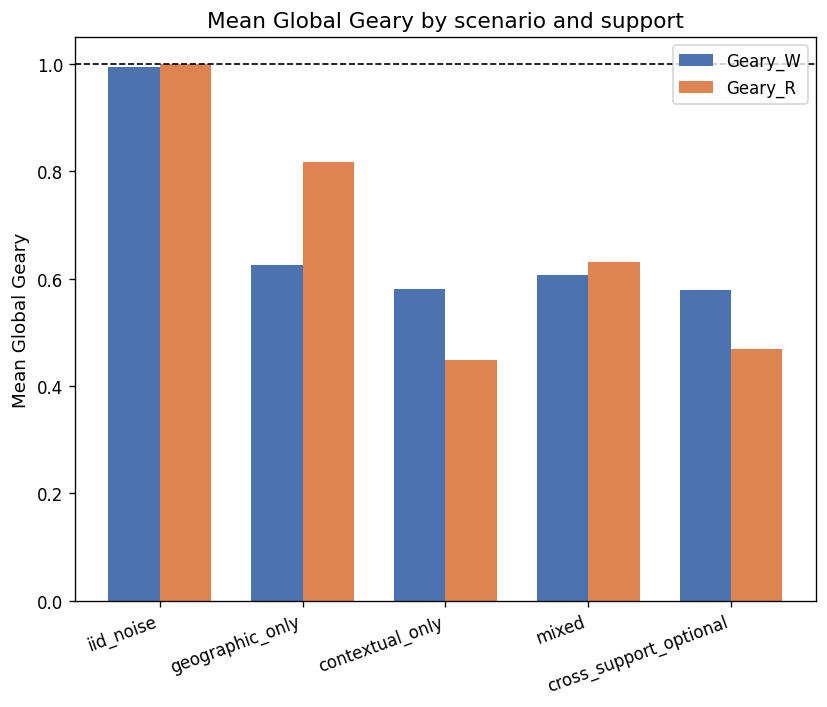

In [17]:
bar_data = summary_table[["Geary_W_mean", "Geary_R_mean"]]
positions = np.arange(len(bar_data))
width = 0.36

fig, ax = plt.subplots()
ax.bar(positions - width / 2, bar_data["Geary_W_mean"], width=width, label="Geary_W", color="#4C72B0")
ax.bar(positions + width / 2, bar_data["Geary_R_mean"], width=width, label="Geary_R", color="#DD8452")
ax.axhline(1.0, color="black", linestyle="--", linewidth=1.0)
ax.set_xticks(positions)
ax.set_xticklabels(bar_data.index, rotation=20, ha="right")
ax.set_ylabel("Mean Global Geary")
ax.set_title("Mean Global Geary by scenario and support")
ax.legend()
plt.tight_layout()
plt.show()

In [18]:
print("Interpretation guide")
print("- Geary near 1 means the process looks random relative to that support.")
print("- Lower Geary means smoother variation relative to that support.")
print("- If Geary_W is lower than Geary_R, geographic support explains the process better.")
print("- If Geary_R is lower than Geary_W, contextual support explains the process better.")
print()

for scenario in SCENARIO_ORDER:
    row = summary_table.loc[scenario]
    better = "W (geographic)" if row["Geary_W_mean"] < row["Geary_R_mean"] else "R (contextual)"
    print(
        f"{scenario:24s}  "
        f"mean Geary_W={row['Geary_W_mean']:.3f}, "
        f"mean Geary_R={row['Geary_R_mean']:.3f}  "
        f"-> stronger support from {better}"
    )

Interpretation guide
- Geary near 1 means the process looks random relative to that support.
- Lower Geary means smoother variation relative to that support.
- If Geary_W is lower than Geary_R, geographic support explains the process better.
- If Geary_R is lower than Geary_W, contextual support explains the process better.

iid_noise                 mean Geary_W=0.993, mean Geary_R=1.000  -> stronger support from W (geographic)
geographic_only           mean Geary_W=0.626, mean Geary_R=0.818  -> stronger support from W (geographic)
contextual_only           mean Geary_W=0.581, mean Geary_R=0.448  -> stronger support from R (contextual)
mixed                     mean Geary_W=0.606, mean Geary_R=0.632  -> stronger support from W (geographic)
cross_support_optional    mean Geary_W=0.578, mean Geary_R=0.469  -> stronger support from R (contextual)


The normalization matters here. Raw energies respond both to roughness and to the total mass of the graph. Because $W$ and $R$ do not generally have the same total edge weight, Geary's normalization is the appropriate comparison scale.

## 11. Inspect one worked example

The worked example below uses the first `contextual_only` draw from the Monte Carlo run.

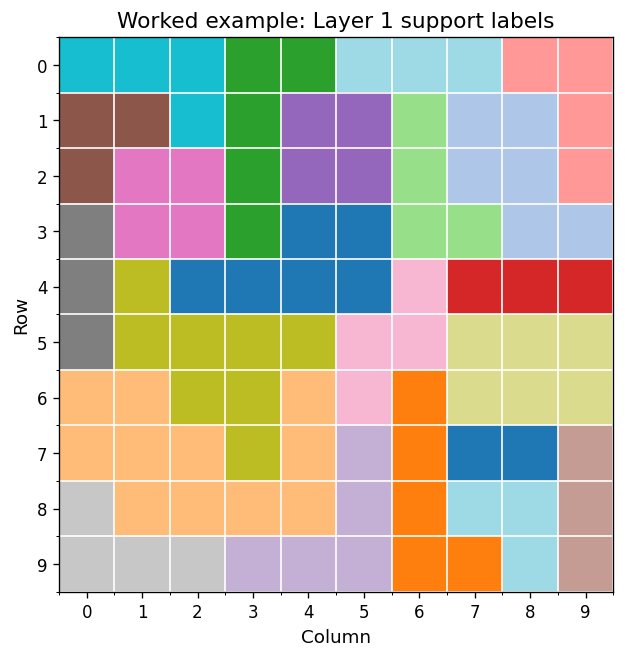

In [19]:
plot_partition(worked.labels1, "Worked example: Layer 1 support labels")

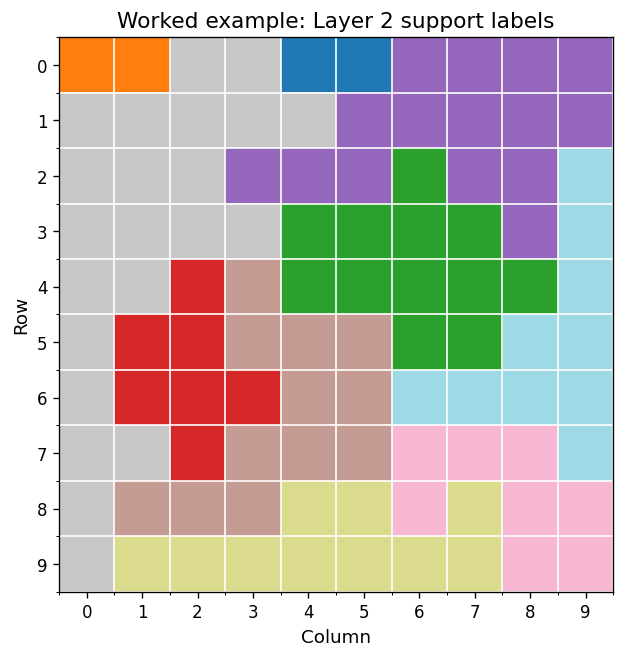

In [20]:
plot_partition(worked.labels2, "Worked example: Layer 2 support labels")

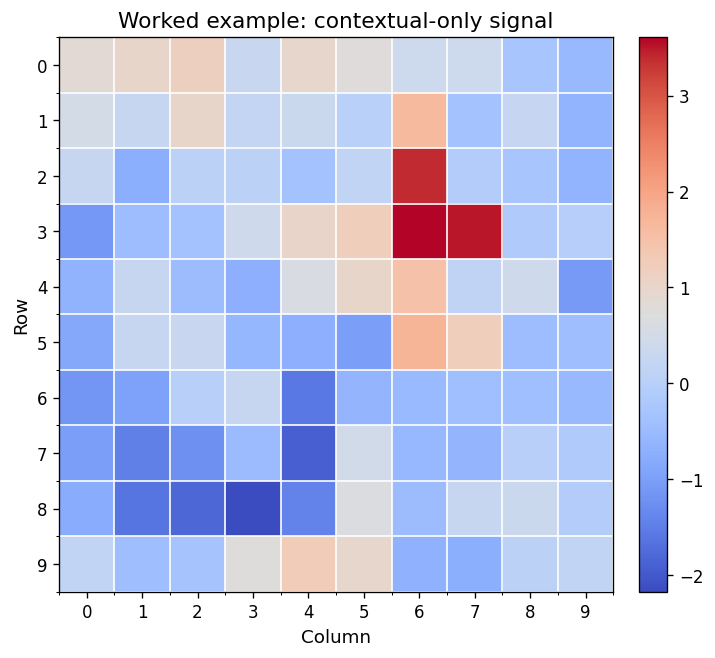

In [21]:
def plot_signal(values: np.ndarray, title: str, cmap: str = "coolwarm") -> None:
    """Plot a lattice-valued signal."""

    fig, ax = plt.subplots()
    im = ax.imshow(values.reshape(N_ROWS, N_COLS), cmap=cmap, interpolation="none")
    ax.set_title(title)
    ax.set_xticks(np.arange(-0.5, N_COLS, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, N_ROWS, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.0)
    ax.set_xticks(range(N_COLS))
    ax.set_yticks(range(N_ROWS))
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.show()


plot_signal(worked.x, "Worked example: contextual-only signal")

In [22]:
rows = np.repeat(np.arange(N_ROWS), N_COLS)
cols = np.tile(np.arange(N_COLS), N_ROWS)

worked_example_table = pd.DataFrame(
    {
        "unit": np.arange(N_CELLS),
        "row": rows,
        "col": cols,
        "layer1_region": worked.labels1,
        "layer2_region": worked.labels2,
        "x": worked.x,
        "LocalGeary_W": worked.local_geary_w,
        "LocalGeary_R": worked.local_geary_r,
        "LocalEnergy_W": worked.local_energy_w,
        "LocalEnergy_R": worked.local_energy_r,
    }
)

with pd.option_context("display.max_rows", None, "display.max_columns", None):
    print(worked_example_table.round(3).to_string(index=False))

 unit  row  col  layer1_region  layer2_region      x  LocalGeary_W  LocalGeary_R  LocalEnergy_W  LocalEnergy_R
    0    0    0             19              1  0.844         0.466         0.170          0.235          0.086
    1    0    1             19              1  0.992         0.806         0.074          0.407          0.038
    2    0    2             19              7  1.169         2.529        49.523          1.277         25.011
    3    0    3              5              7  0.309         1.655        16.201          0.836          8.182
    4    0    4              5              0  0.980         2.351         2.201          1.187          1.112
    5    0    5             21              0  0.749         1.605         0.309          0.811          0.156
    6    0    6             21              4  0.396         2.284         6.220          1.154          3.141
    7    0    7             21              4  0.383         2.490         6.089          1.257          3.075
 

This worked example table is where the local diagnostics become useful:

- `LocalEnergy_W` and `LocalGeary_W` show where the signal is rough relative to geographic adjacency
- `LocalEnergy_R` and `LocalGeary_R` show where the signal is rough relative to contextual support

The two need not highlight the same cells.

## 12. Interpretation and discussion

This simulation lab is designed to make one conceptual distinction explicit:

- $W$ defines **geographic autocorrelation**
- $R$ defines **contextual autocorrelation across combined supports**

That difference is structural, not cosmetic. A process can be smooth over the chosen geographic graph but rough over contextual supports, or vice versa.

When the data-generating process is geographic, `Geary_W` should drop more strongly than `Geary_R`. When the process is contextual, `Geary_R` should drop more strongly. Under iid noise, both statistics should stay near `1`. Mixed processes should usually register signal in both graphs.

Graph-theoretically, $R$ is a contextual similarity graph induced by shared support membership, not by geographic adjacency. Once built, however, it can be analyzed with the same Laplacian and spectral tools used for ordinary spatial graphs [@chung1997spectral; @griffith2000linear; @tiefelsdorf2007semiparametric; @mahdi2019efficient].

## 13. Extensions and exercises

1. Change the number or size range of the overlay polygons and rerun the Monte Carlo experiment.
2. Increase or decrease the iid noise variance in the contextual and mixed processes.
3. Change the balance between the geographic and contextual components in the mixed scenario.
4. Switch `GEOGRAPHIC_CONTIGUITY` between `"queen"` and `"rook"` and compare how the Monte Carlo summaries shift.
5. Replace binary incidence with weighted overlap and redefine $R$ from that weighted $B$.
6. Compare raw energy and normalized Geary more carefully for graphs with very different total edge weight.
7. Build a RelWeights-based local diagnostic map and compare it with the geographic local map.
8. Add a permutation test for $C_W$ and $C_R$ to study significance as well as magnitude.